# script to calculate the absolute coordinates of head position measured with DLC from center coordinates
(excluded worms from june head position has more oordinates then center stage)

In [1]:
#Importing the toolbox (takes several seconds)
import pandas as pd
from pathlib import Path
import numpy as np
import os
import matplotlib.pyplot as plt
import tifffile as tiff
from natsort import natsorted
import glob
import matplotlib.patches as patches
from coordinate_conversion_functions import *
from track_plotting_daniel import *

## read in data

In [2]:
#this are the center coordinates
path_center_coords='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_tracks/2020-07-01_17-01-27_chemotaxis_worm6-TablePosRecord.txt'
df_center_coords=pd.read_csv(path_center_coords)
df_center_coords

,time,xc,x,yc,y
0,17:01:30.648,x,33.4918,y,9.3320
1,17:01:30.665,x,33.4918,y,9.3320
2,17:01:30.665,x,33.4918,y,9.3320
3,17:01:30.665,x,33.4918,y,9.3320
4,17:01:30.680,x,33.4911,y,9.3314
...,...,...,...,...,...
199996,17:21:30.657,x,9.0679,y,16.2026
199997,17:21:30.673,x,9.0679,y,16.2025
199998,17:21:30.673,x,9.0679,y,16.2024
199999,17:21:30.689,x,9.0679,y,16.2021


In [3]:
#this are the head and tail positions measured via dlc
path_head_tail='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/avi_all/2020-07-01_17-01-27_chemotaxis_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5'
df_head_tail_coords=pd.read_hdf(path_head_tail, low_memory=False)
df_head_tail_coords

scorer    DLC_resnet50_HeadTailAug10shuffle1_275000                         \
bodyparts                                      Head                          
coords                                            x           y likelihood   
0                                        389.711609  210.913239   0.996472   
1                                        390.144379  210.976715   0.991877   
2                                        390.594421  210.976715   0.986385   
3                                        390.903259  211.140228   0.969252   
4                                        391.174713  211.142487   0.983928   
...                                             ...         ...        ...   
199996                                   360.581543  179.774857   0.998283   
199997                                   360.563049  179.774857   0.997769   
199998                                   360.563049  179.774857   0.998213   
199999                                   360.388428  179.774857   0.998692   
200000                                   360.346466  179.774857   0.998626   

scorer                                        
bodyparts        Tail                         
coords              x           y likelihood  
0          186.799408  451.260254   0.987140  
1          187.362625  451.527924   0.977224  
2          187.374374  451.623749   0.965021  
3          187.554306  451.848267   0.965582  
4          188.050034  451.918915   0.967007  
...               ...         ...        ...  
199996     325.068146  465.529633   0.994418  
199997     325.054749  465.529633   0.995057  
199998     325.054749  465.497864   0.995303  
199999     324.962982  465.497864   0.995747  
200000     324.734741  464.959076   0.995751  

[200001 rows x 6 columns]

# get absolute head and tail coordinates

In [4]:
scorer=df_head_tail_coords.columns.get_level_values(0)[0] # defines scorer as the first column of the dataframe",
df_head_tail_center_coords=df_center_coords
df_head_tail_center_coords=df_head_tail_center_coords.rename(columns = {'x': 'x_center',
                'y': 'y_center'}, inplace = False)
df_head_tail_center_coords

,time,xc,x_center,yc,y_center
0,17:01:30.648,x,33.4918,y,9.3320
1,17:01:30.665,x,33.4918,y,9.3320
2,17:01:30.665,x,33.4918,y,9.3320
3,17:01:30.665,x,33.4918,y,9.3320
4,17:01:30.680,x,33.4911,y,9.3314
...,...,...,...,...,...
199996,17:21:30.657,x,9.0679,y,16.2026
199997,17:21:30.673,x,9.0679,y,16.2025
199998,17:21:30.673,x,9.0679,y,16.2024
199999,17:21:30.689,x,9.0679,y,16.2021


In [5]:
#defining the parameters for the function to calulate the corrected head and tail positions
px_mm=0.00325 # this value represents how much mm is one pixel
x_lenght_frame=608 #lenght of x axis in frame (measured with fiji)
y_width_frame=610 #width of the y axis in frame
center_x=df_head_tail_center_coords['x_center'] #absolute coordinates of center position x
center_y=df_head_tail_center_coords['y_center'] #absolute coordinates of center position y
data_head_x=df_head_tail_coords[scorer]['Head']['x'].values #getting the x position of head
data_head_y=df_head_tail_coords[scorer]['Head']['y'].values #getting the y position of head
data_tail_x=df_head_tail_coords[scorer]['Tail']['x'].values #getting the x position of tail
data_tail_y=df_head_tail_coords[scorer]['Tail']['y'].values #getting the y position of tail

In [6]:
#create absolute coordinates for head
corrected_head_position=corrected_absolute_coordinates(center_x,center_y,data_head_x,
                data_head_y,px_mm,y_width_frame,x_lenght_frame)

corrected_head_position= corrected_head_position.rename(columns = {'x_corrected': 'x_head_corrected',
                'y_corrected': 'y_head_corrected'}, inplace = False)

corrected_tail_position=corrected_absolute_coordinates(center_x,center_y,data_tail_x,
                                                       data_tail_y,px_mm,y_width_frame,x_lenght_frame)
#create absolute coordinates for tail
corrected_tail_position= corrected_tail_position.rename(columns = {'x_corrected': 'x_tail_corrected',
                'y_corrected': 'y_tail_corrected'}, inplace = False)

In [7]:
#joining dfs for center coords and corrected head and tail coordinates
df_head_tail_center_coords = pd.concat([df_head_tail_center_coords,corrected_head_position, 
                                        corrected_tail_position], axis=1)
#df_head_tail_center_coords

In [8]:
#corrected for food position
xref=9.10
df_head_tail_center_coords['x_tail_corrected']=df_head_tail_center_coords['x_tail_corrected']-xref
df_head_tail_center_coords['x_head_corrected']=df_head_tail_center_coords['x_head_corrected']-xref
df_head_tail_center_coords['x_center']=df_head_tail_center_coords['x_center']-xref
df_head_tail_center_coords

,time,xc,x_center,yc,y_center,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
0,17:01:30.648,x,24.3918,y,9.3320,24.113237,9.026218,24.772702,9.807346
1,17:01:30.665,x,24.3918,y,9.3320,24.111831,9.026424,24.770871,9.808216
2,17:01:30.665,x,24.3918,y,9.3320,24.110368,9.026424,24.770833,9.808527
3,17:01:30.665,x,24.3918,y,9.3320,24.109364,9.026956,24.770249,9.809257
4,17:01:30.680,x,24.3911,y,9.3314,24.107782,9.026363,24.767937,9.808886
...,...,...,...,...,...,...,...,...,...
199996,17:21:30.657,x,-0.0321,y,16.2026,-0.215990,15.795618,-0.100571,16.724321
199997,17:21:30.673,x,-0.0321,y,16.2025,-0.215930,15.795518,-0.100528,16.724221
199998,17:21:30.673,x,-0.0321,y,16.2024,-0.215930,15.795418,-0.100528,16.724018
199999,17:21:30.689,x,-0.0321,y,16.2021,-0.215362,15.795118,-0.100230,16.723718


## calculate concentration change and put it in a dataframe with the coordinates

In [9]:
#this is telling you the concentration of every x position occuring in the data
#since it is a stripe assay only the x coordinates matter for concentration change
#parameters determined via the curve fit script
L=1
x0=3.81953189
k=-0.69421567
b=0
x_head_corrected=df_head_tail_center_coords['x_head_corrected'].values 
x_tail_corrected=df_head_tail_center_coords['x_tail_corrected'].values
x_center=df_head_tail_center_coords['x_center'].values
y_head_corrected=df_head_tail_center_coords['y_head_corrected'].values 
y_tail_corrected=df_head_tail_center_coords['y_tail_corrected'].values
y_center=df_head_tail_center_coords['y_center'].values
y_fit_head=sigmoid(x_head_corrected, L, x0, k, b)
y_fit_tail=sigmoid(x_tail_corrected, L, x0, k, b)
y_fit_center=sigmoid(x_center, L, x0, k, b)

In [10]:
#creating df with x y head/tail position and the corresponding concentration
position_concentration = pd.DataFrame(data=x_head_corrected,columns=["x_head_corrected"])
position_concentration['y_head_corrected']=pd.DataFrame(data=y_head_corrected,columns=["y_head_corrected"])
position_concentration['x_tail_corrected']=pd.DataFrame(data=x_tail_corrected,columns=["x_tail_corrected"])
position_concentration['y_tail_corrected']=pd.DataFrame(data=y_tail_corrected,columns=["y_tail_corrected"])
position_concentration['x_center']=pd.DataFrame(data=x_center,columns=["x_center"])
position_concentration['y_center']=pd.DataFrame(data=y_center,columns=["y_center"])
position_concentration['concentration_head']=y_fit_head
position_concentration['concentration_tail']=y_fit_tail
position_concentration['concentration_center']=y_fit_center
position_concentration

,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected,x_center,y_center,concentration_head,concentration_tail,concentration_center
0,24.113237,9.026218,24.772702,9.807346,24.3918,9.3320,7.613223e-07,4.816638e-07,6.274565e-07
1,24.111831,9.026424,24.770871,9.808216,24.3918,9.3320,7.620660e-07,4.822763e-07,6.274565e-07
2,24.110368,9.026424,24.770833,9.808527,24.3918,9.3320,7.628402e-07,4.822890e-07,6.274565e-07
3,24.109364,9.026956,24.770249,9.809257,24.3918,9.3320,7.633720e-07,4.824849e-07,6.274565e-07
4,24.107782,9.026363,24.767937,9.808886,24.3911,9.3314,7.642109e-07,4.832596e-07,6.277615e-07
...,...,...,...,...,...,...,...,...,...
199996,-0.215990,15.795618,-0.100571,16.724321,-0.0321,16.2026,9.427580e-01,9.382775e-01,9.354666e-01
199997,-0.215930,15.795518,-0.100528,16.724221,-0.0321,16.2025,9.427558e-01,9.382757e-01,9.354666e-01
199998,-0.215930,15.795418,-0.100528,16.724018,-0.0321,16.2024,9.427558e-01,9.382757e-01,9.354666e-01
199999,-0.215362,15.795118,-0.100230,16.723718,-0.0321,16.2021,9.427345e-01,9.382638e-01,9.354666e-01


In [11]:
#calculating concentration change
concentration_change=position_concentration
concentration_change["concentration_change_head"] = position_concentration["concentration_head"].diff()
concentration_change["concentration_change_tail"] = position_concentration["concentration_tail"].diff()
concentration_change["concentration_change_center"] = position_concentration["concentration_center"].diff()
concentration_change['seconds']=np.arange(0, len(concentration_change)/fps,1/fps)
concentration_change

NameError: name 'fps' is not defined

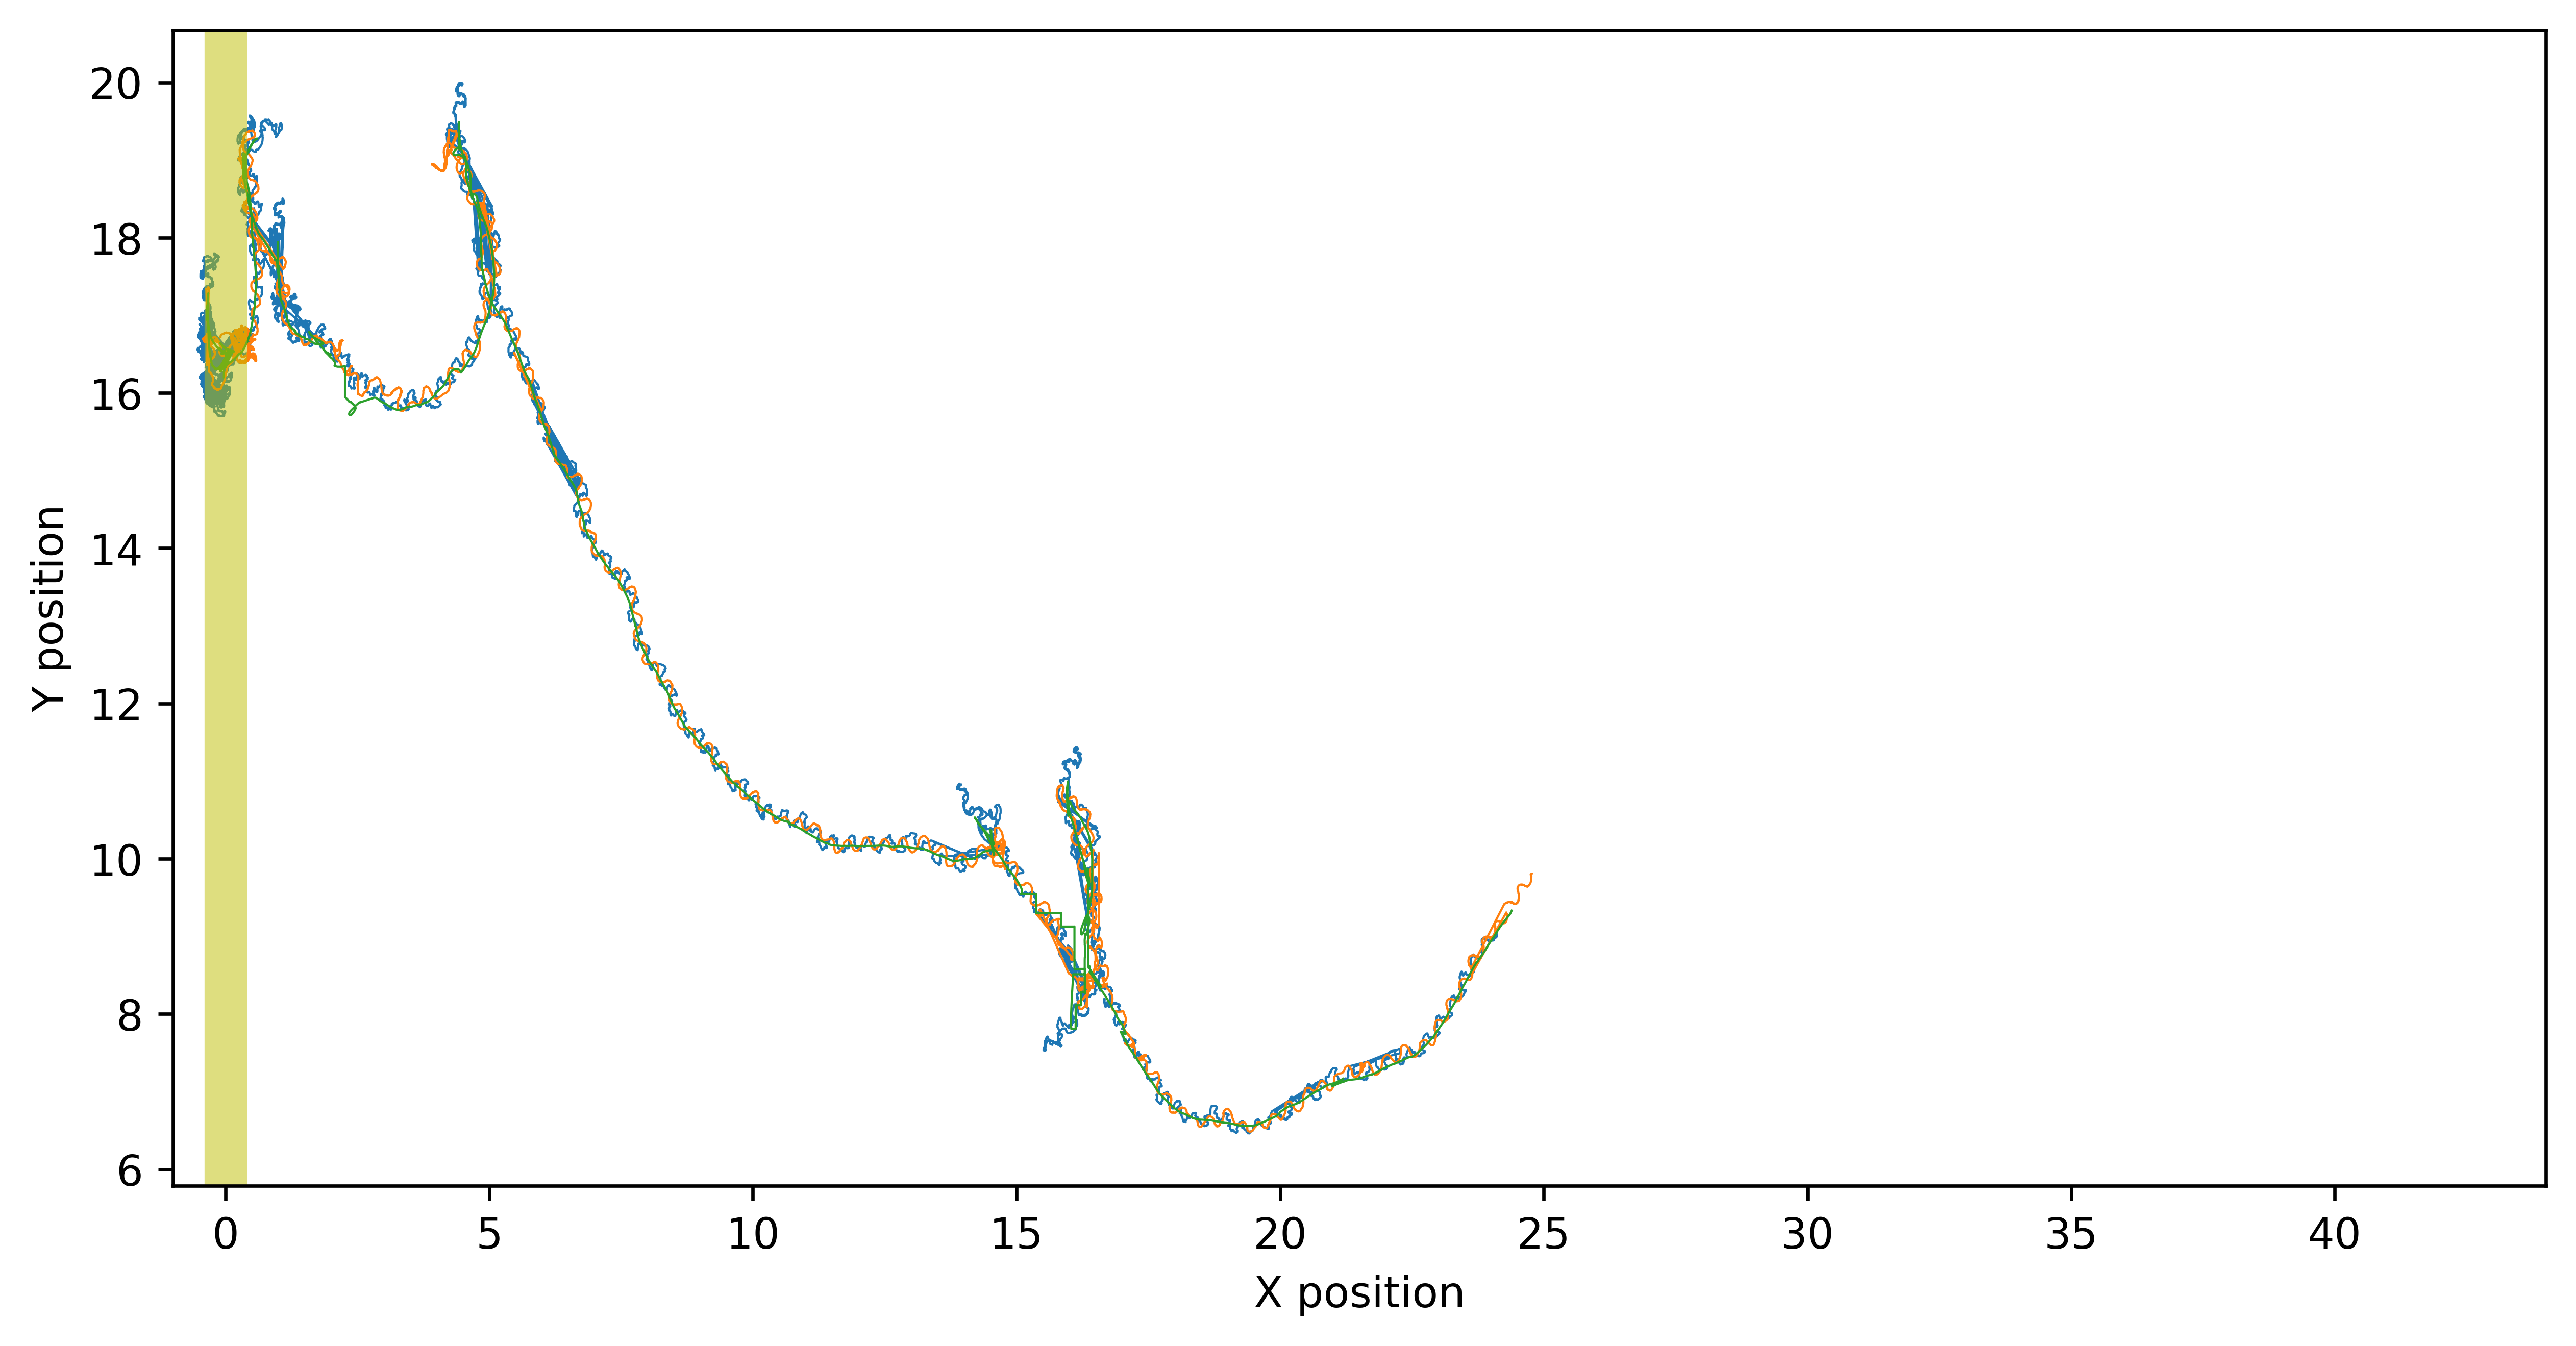

In [12]:
#plot track
line_width=0.5
head_conc=concentration_change['concentration_head']
tail_conc=concentration_change['concentration_tail']
center_conc=concentration_change['concentration_center']

head_pos_x=concentration_change['x_head_corrected']
tail_pos_x=concentration_change['x_tail_corrected']
center_pos_x=concentration_change['x_center']

head_pos_y=df_head_tail_center_coords['y_head_corrected']
tail_pos_y=df_head_tail_center_coords['y_tail_corrected']
center_pos_y=df_head_tail_center_coords['y_center']

fig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=600)
#ax3.scatter(head_pos_x,head_pos_y,c=head_conc,s=0.01)
#ax3.scatter(tail_pos_x,tail_pos_y,c=tail_conc,s=0.01)
#ax3.scatter(center_pos_x,center_pos_y,c=center_conc,s=0.01)
ax3.plot(head_pos_x,head_pos_y,linewidth=line_width)
ax3.plot(tail_pos_x,tail_pos_y,linewidth=line_width)
ax3.plot(center_pos_x,center_pos_y,linewidth=line_width)
ax3.axvline(x=0, ymin=0, ymax=1, lw=10, alpha=.5, color='y')
plt.xlim(-1,44)
plt.xlabel('X position')
plt.ylabel('Y position')
plt.show()

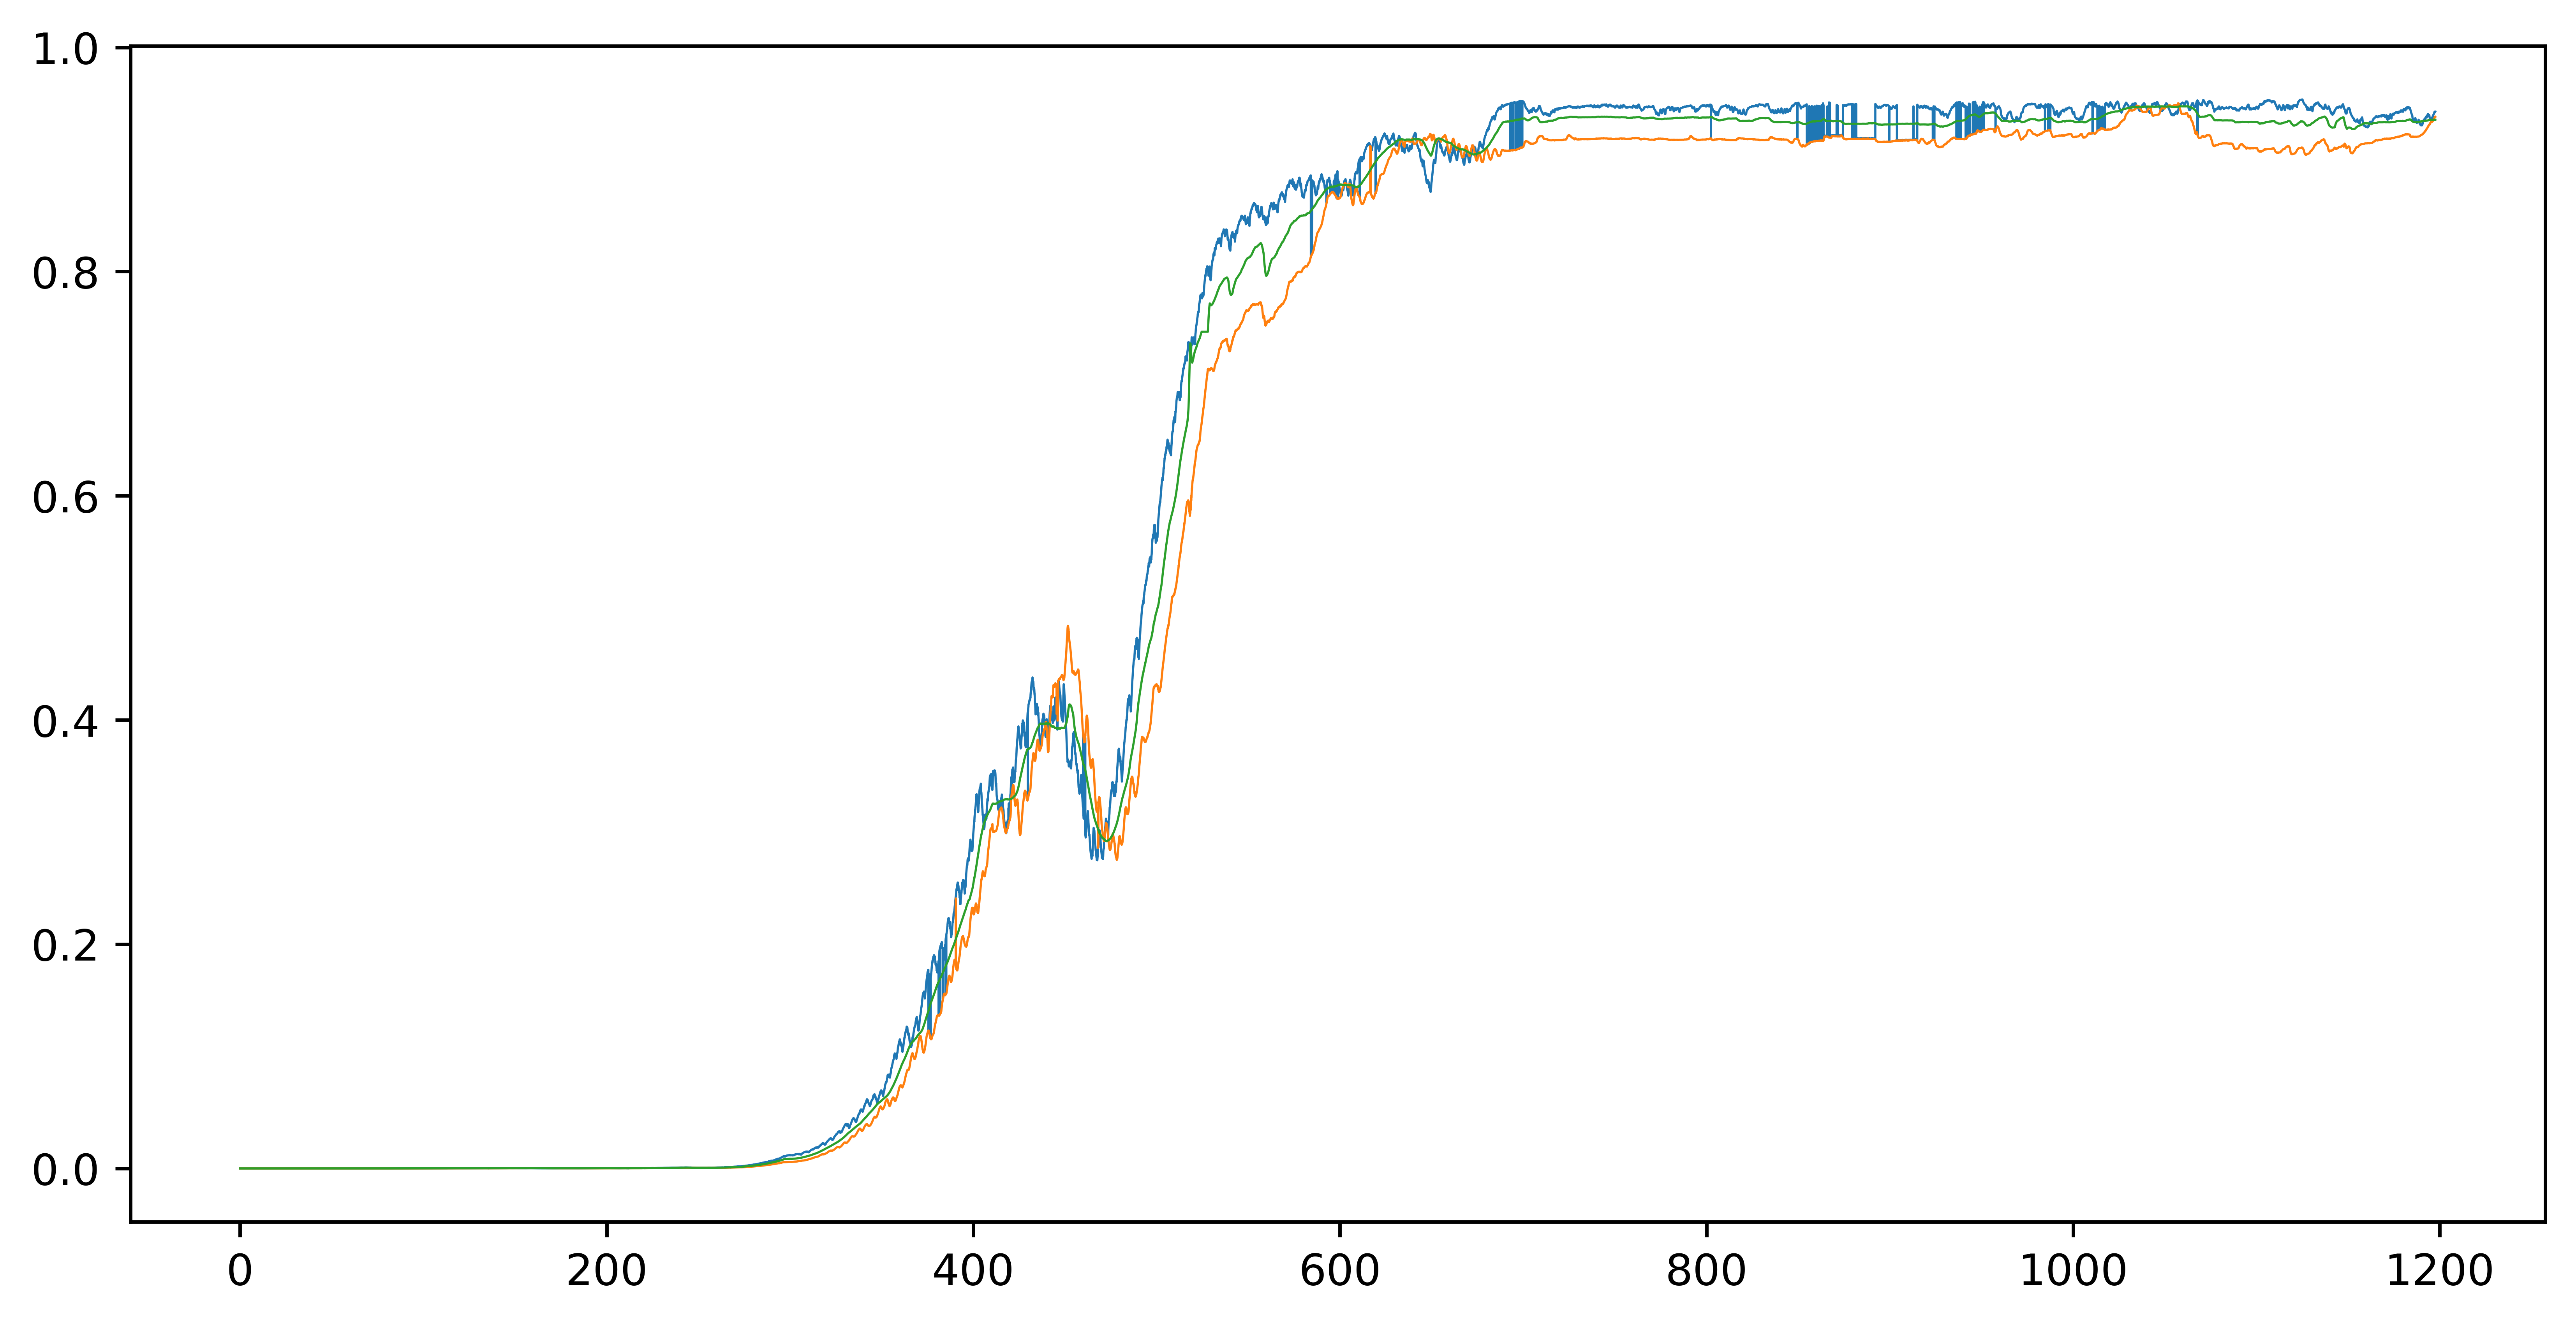

In [122]:
#concentraton and time
line_width=0.5
x=concentration_change['seconds']
head_conc=concentration_change['concentration_head']
tail_conc=concentration_change['concentration_tail']
center_conc=concentration_change['concentration_center']
xfig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=800)
ax3.plot(x,head_conc,label="head",linewidth=line_width)
ax3.plot(x,tail_conc,label="tail",linewidth=line_width)
ax3.plot(x,center_conc,label="center",linewidth=line_width)
plt.show()

## csv files with corrected coordinates and concentration for all worms

In [ ]:
#defining the parameters for the function to calulate the corrected head and tail positions
px_mm=0.00325 # this value represents how much mm is one pixel
x_lenght_frame=608 #lenght of x axis in frame (measured with fiji)
y_width_frame=610 #width of the y axis in frame

In [ ]:
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/all_x_refs.csv'
all_x_ref=pd.read_csv(path)
all_x_ref

In [ ]:
#loop to create csv with absolute heasd and tail coordinates + correction for xref
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/'
all_x_ref=pd.read_csv('/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/all_x_refs.csv')
for i, folder in enumerate(natsorted(os.listdir(path))):   
    x_ref=all_x_ref['x_ref'][i] 
    #print(i, ': x ref of ', folder, 'is: ', x_ref)
    hdf5_files=glob.glob(os.path.join(path,folder,'*.h5'))
    txt_files=glob.glob(os.path.join(path,folder,'*.txt'))
    #acces the first (and should be only hdf5 file)
    hdf5_file=hdf5_files[0]
    df_head_tail=pd.read_hdf(hdf5_file)
    #print(df_head_tail)
    scorer= df_head_tail.columns.get_level_values(0)[0]
    data_head_x= df_head_tail[scorer]['Head']['x'].values #getting the x position of head
    data_head_y=df_head_tail[scorer]['Head']['y'].values #getting the y position of head
    data_tail_x=df_head_tail[scorer]['Tail']['x'].values #getting the x position of tail
    data_tail_y=df_head_tail[scorer]['Tail']['y'].values #getting the y position of tail
    txt_file=txt_files[0]
    df_center_coords=pd.read_csv(txt_file)
    #print(df_center_coords)
    if len(df_center_coords) > len(df_head_tail):
        rows_diff=len(df_center_coords) - len(df_head_tail)
        print(txt_files,'is',rows_diff,' rows longer')
        df_center_coords.drop(df_center_coords.tail(rows_diff).index,inplace=True)
    df_center_coords = df_center_coords[0:200001] #some center coordinates have more rows than dlc data
    #print(df_center_coords)
    df_center_coords = df_center_coords.rename(columns={"x":"x_center"})
    df_center_coords = df_center_coords.rename(columns={"y":"y_center"})
    #print(df_center_coords)
    center_x=df_center_coords['x_center'].values #absolute coordinates of center position x
    center_y=df_center_coords['y_center'].values #absolute coordinates of center position y
    #print(df_head_tail)
    corrected_head=corrected_absolute_coordinates(center_x,center_y,data_head_x, data_head_y,px_mm,y_width_frame,x_lenght_frame)  #fucntion to calculate absolute x coordinates for head and tial
    corrected_tail=corrected_absolute_coordinates(center_x,center_y,data_tail_x,data_tail_y,px_mm,y_width_frame,x_lenght_frame)
    corrected_head = corrected_head.rename(columns={"x_corrected":"x_head_corrected"}) #rename to have differnt column names for head and tail when the df is put togeether
    corrected_head = corrected_head.rename(columns={"y_corrected":"y_head_corrected"})
    corrected_tail = corrected_tail.rename(columns={"x_corrected":"x_tail_corrected"})
    corrected_tail = corrected_tail.rename(columns={"y_corrected":"y_tail_corrected"})
    df_head_tail_center_coords=pd.concat([df_center_coords,corrected_head,corrected_tail], axis=1)
    df_head_tail_center_coords['x_head_corrected']=df_head_tail_center_coords['x_head_corrected']-x_ref  #correcting for xref
    df_head_tail_center_coords['x_tail_corrected']=df_head_tail_center_coords['x_tail_corrected']-x_ref
    df_head_tail_center_coords['x_center']=df_head_tail_center_coords['x_center']-x_ref
    #print(df_head_tail_center_coords)
    #df_head_tail_center_coords.to_csv('/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/'+folder+'.csv')

In [ ]:
#this is telling you the concentration of every x position occuring in the data
#parameters determined via the curve fit script
L=1
x0=3.81953189
k=-0.69421567
b=0

In [ ]:
#creates csv files with concentration data
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected/'
for filename in natsorted(os.listdir(path)):
    df_head_tail_center_coords=pd.read_csv(path+filename)
    x_head_corrected=df_head_tail_center_coords['x_head_corrected'].values #xref adust gradient for food position
    x_tail_corrected=df_head_tail_center_coords['x_tail_corrected'].values
    y_head_corrected=df_head_tail_center_coords['y_head_corrected'].values 
    y_tail_corrected=df_head_tail_center_coords['y_tail_corrected'].values
    y_center=df_head_tail_center_coords['y_center'].values
    x_center=df_head_tail_center_coords['x_center'].values
    y_fit_head=sigmoid(x_head_corrected, L, x0, k, b)
    y_fit_tail=sigmoid(x_tail_corrected, L, x0, k, b)
    y_fit_center=sigmoid(x_center, L, x0, k, b)
    #creating df with x/y head/tail position and the corresponding concentration
    position_concentration = pd.DataFrame(data=x_head_corrected,columns=["x_head_corrected"])
    position_concentration['y_head_corrected']=pd.DataFrame(data=y_head_corrected,columns=["y_head_corrected"])
    position_concentration['x_tail_corrected']=pd.DataFrame(data=x_tail_corrected,columns=["x_tail_corrected"])
    position_concentration['y_tail_corrected']=pd.DataFrame(data=y_tail_corrected,columns=["y_tail_corrected"])
    position_concentration['x_center']=pd.DataFrame(data=x_center,columns=["x_center"])
    position_concentration['y_center']=pd.DataFrame(data=y_center,columns=["y_center"])
    position_concentration['concentration_head']=y_fit_head
    position_concentration['concentration_tail']=y_fit_tail
    position_concentration['concentration_center']=y_fit_center
    #calculating concentration change
    concentration_change=position_concentration
    concentration_change["concentration_change_head"] = position_concentration["concentration_head"].diff()
    concentration_change["concentration_change_tail"] = position_concentration["concentration_tail"].diff()
    concentration_change["concentration_change_center"] = position_concentration["concentration_center"].diff()
    concentration_change['seconds']=np.arange(0, len(concentration_change)/fps,1/fps)
    #print(concentration_change)
    #concentration_change.to_csv('/groups/zimmer//Daniel_Mitic/data/ulises_chemotaxis/'+filename+'concentration.csv', index=False)

## plot all tracks

In [ ]:
figsize_x=10
figsize_y=5
line_width=0.1
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected_concentration/'
#plot all tracks for center head and tail
for filename in natsorted(os.listdir(path)):
    plot_tracks_center_head_tail(path+filename,figsize_x,figsize_y,line_width)
    plt.title(filename)
    plt.xlabel('X position')
    plt.ylabel('Y posiiton')
    #plt.savefig(path+filename+'.png')

## plot concentration over time

In [ ]:
#concentraton and time for all tracks
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected_concentration/'
line_width=0.1
x=np.arange(200001)

for filename in natsorted(os.listdir(path)):
    concentration_change=pd.read_csv(path+filename)
    head_conc=concentration_change['concentration_head']
    tail_conc=concentration_change['concentration_tail']
    center_conc=concentration_change['concentration_center']

    xfig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=600)
    ax3.plot(x,head_conc,label="head",linewidth=line_width)
    ax3.plot(x,tail_conc,label="tail",linewidth=line_width)
    ax3.plot(x,center_conc,label="center",linewidth=line_width)
    plt.title(filename)
    plt.xlabel('time')
    plt.legend()
    plt.ylabel('concentration')
    plt.ylim([0,1])
    #plt.savefig(path+filename+'.png')

In [ ]:
#histogram concentration change for all worms
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected_concentration/'
output_path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/'
bins = np.linspace(-0.0015, 0.0015, 500)
for filename in natsorted(os.listdir(path)):
    print(filename)
    concentration_change=pd.read_csv(path+filename)
    head_conc=concentration_change['concentration_change_head']
    tail_conc=concentration_change['concentration_change_tail']
    center_conc=concentration_change['concentration_change_center']
    plt.xticks(np.arange(-0.0015, 0.0015, step=0.00005)) 
    plt.hist(head_conc, bins, alpha=0.5, label='head_conc')
    plt.hist(tail_conc, bins, alpha=0.5, label='tail_conc')
    plt.hist(center_conc, bins, alpha=0.5, label='center_conc')
    plt.legend(loc='upper right')
    plt.ylim(0, 10000)
    plt.xlim(-0.00015, 0.00015)
    #plt.savefig(output_path+filename+'.png')
    plt.show()

## single worms

In [14]:
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected_concentration/2020-07-01_14-41-11_chemotaxisl_worm2-TablePosRecord.csvconcentration.csv'
concentration_change=pd.read_csv(path, low_memory=False)
concentration_change

,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected,x_center,y_center,concentration_head,concentration_tail,concentration_center,concentration_change_head,concentration_change_tail,concentration_change_center,seconds
0,14.962800,15.022802,16.040837,15.092046,15.4866,15.1372,0.000437,0.000207,0.000304,NaN,NaN,NaN,0.000000
1,14.810655,14.990773,15.887005,15.059743,15.3373,15.1046,0.000485,0.000230,0.000337,4.862489e-05,2.328620e-05,3.314557e-05,0.005988
2,14.810535,14.992948,15.887005,15.060383,15.3373,15.1046,0.000485,0.000230,0.000337,4.041583e-08,0.000000e+00,0.000000e+00,0.011976
3,14.810414,14.993450,15.887005,15.060505,15.3373,15.1046,0.000485,0.000230,0.000337,4.095368e-08,0.000000e+00,0.000000e+00,0.017964
4,14.810314,14.995230,15.886905,15.060579,15.3372,15.1046,0.000485,0.000230,0.000337,3.368236e-08,1.596021e-08,2.337107e-08,0.023952
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199996,-0.216802,26.147656,0.091517,25.106452,-0.0166,25.6222,0.942788,0.930088,0.934814,0.000000e+00,-1.546250e-05,0.000000e+00,1197.580838
199997,-0.216802,26.147756,0.091581,25.106552,-0.0166,25.6223,0.942788,0.930085,0.934814,0.000000e+00,-2.914683e-06,0.000000e+00,1197.586826
199998,-0.216802,26.147856,0.091646,25.106535,-0.0166,25.6224,0.942788,0.930082,0.934814,0.000000e+00,-2.910317e-06,0.000000e+00,1197.592814
199999,-0.216842,26.147410,0.091546,25.106166,-0.0167,25.6224,0.942790,0.930087,0.934818,1.501296e-06,4.514285e-06,4.230199e-06,1197.598802


## Plotting specific sections

lenght of section: 63.6167664670659 secs


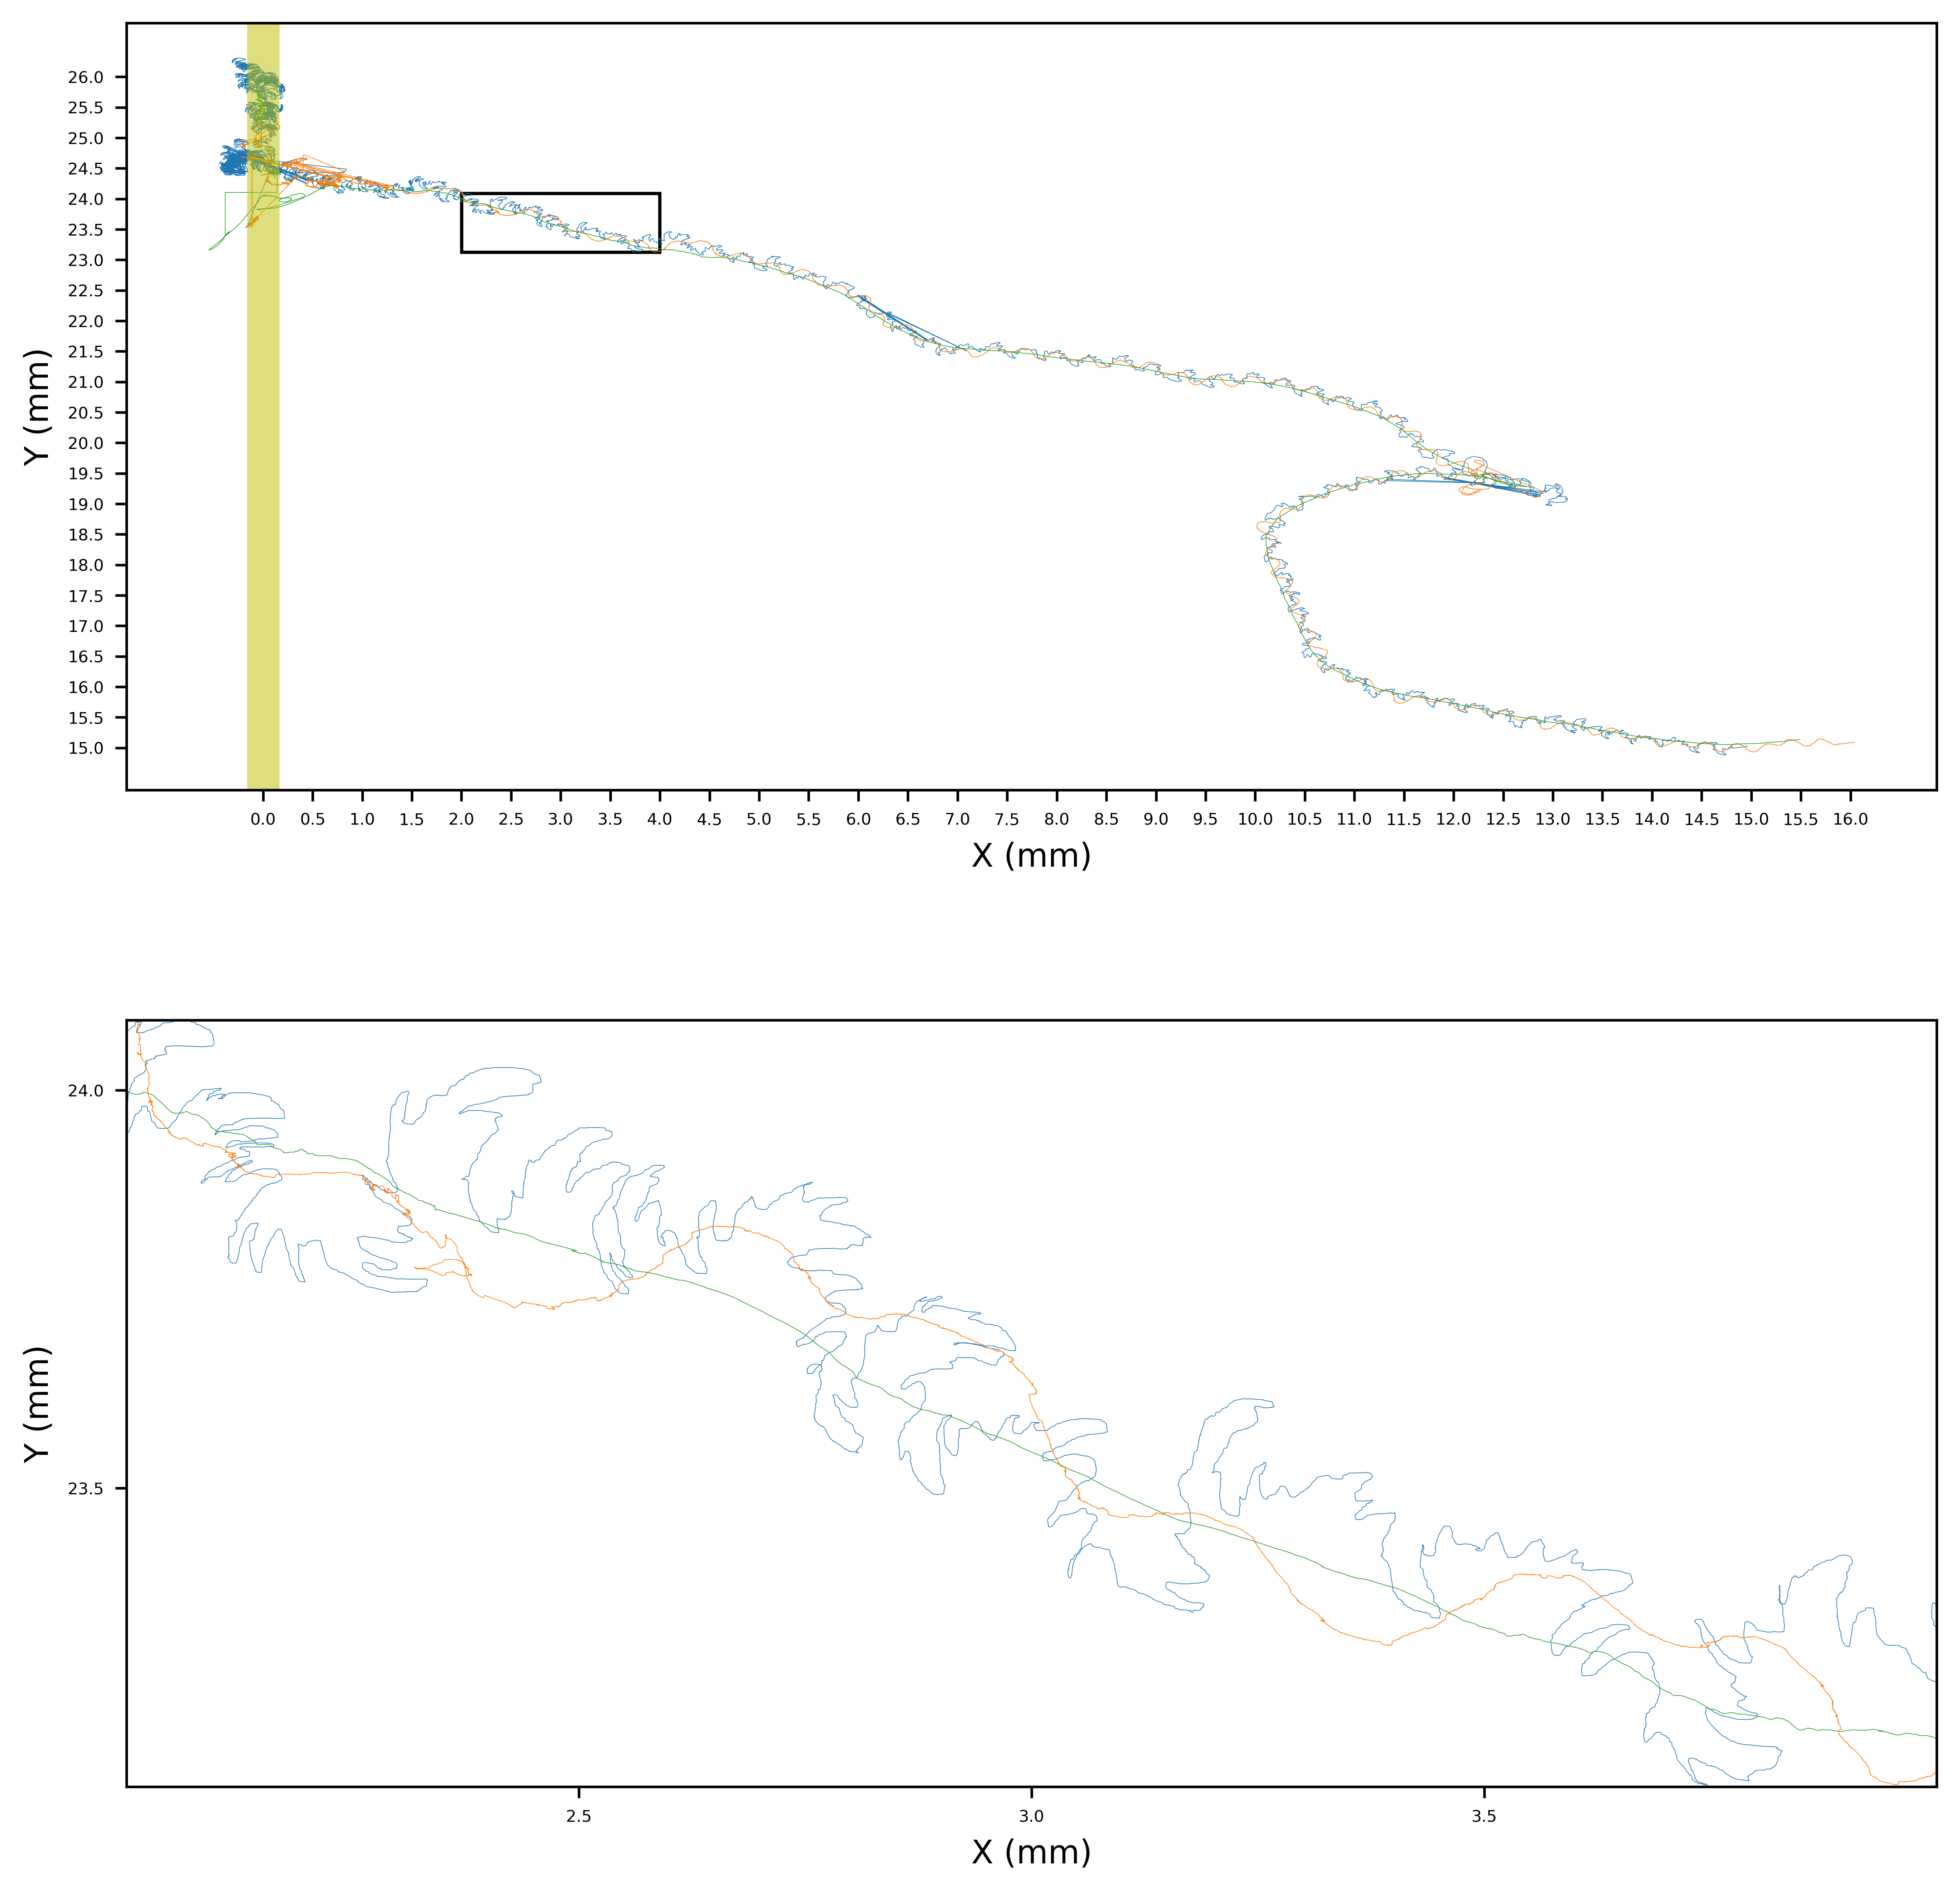

In [15]:
begin_x=2
end_x=4
begin_y=22
end_y=24.88
position=position_to_time(concentration_change,begin_x,end_x,begin_y,end_y)
plot_track_section(concentration_change,position)

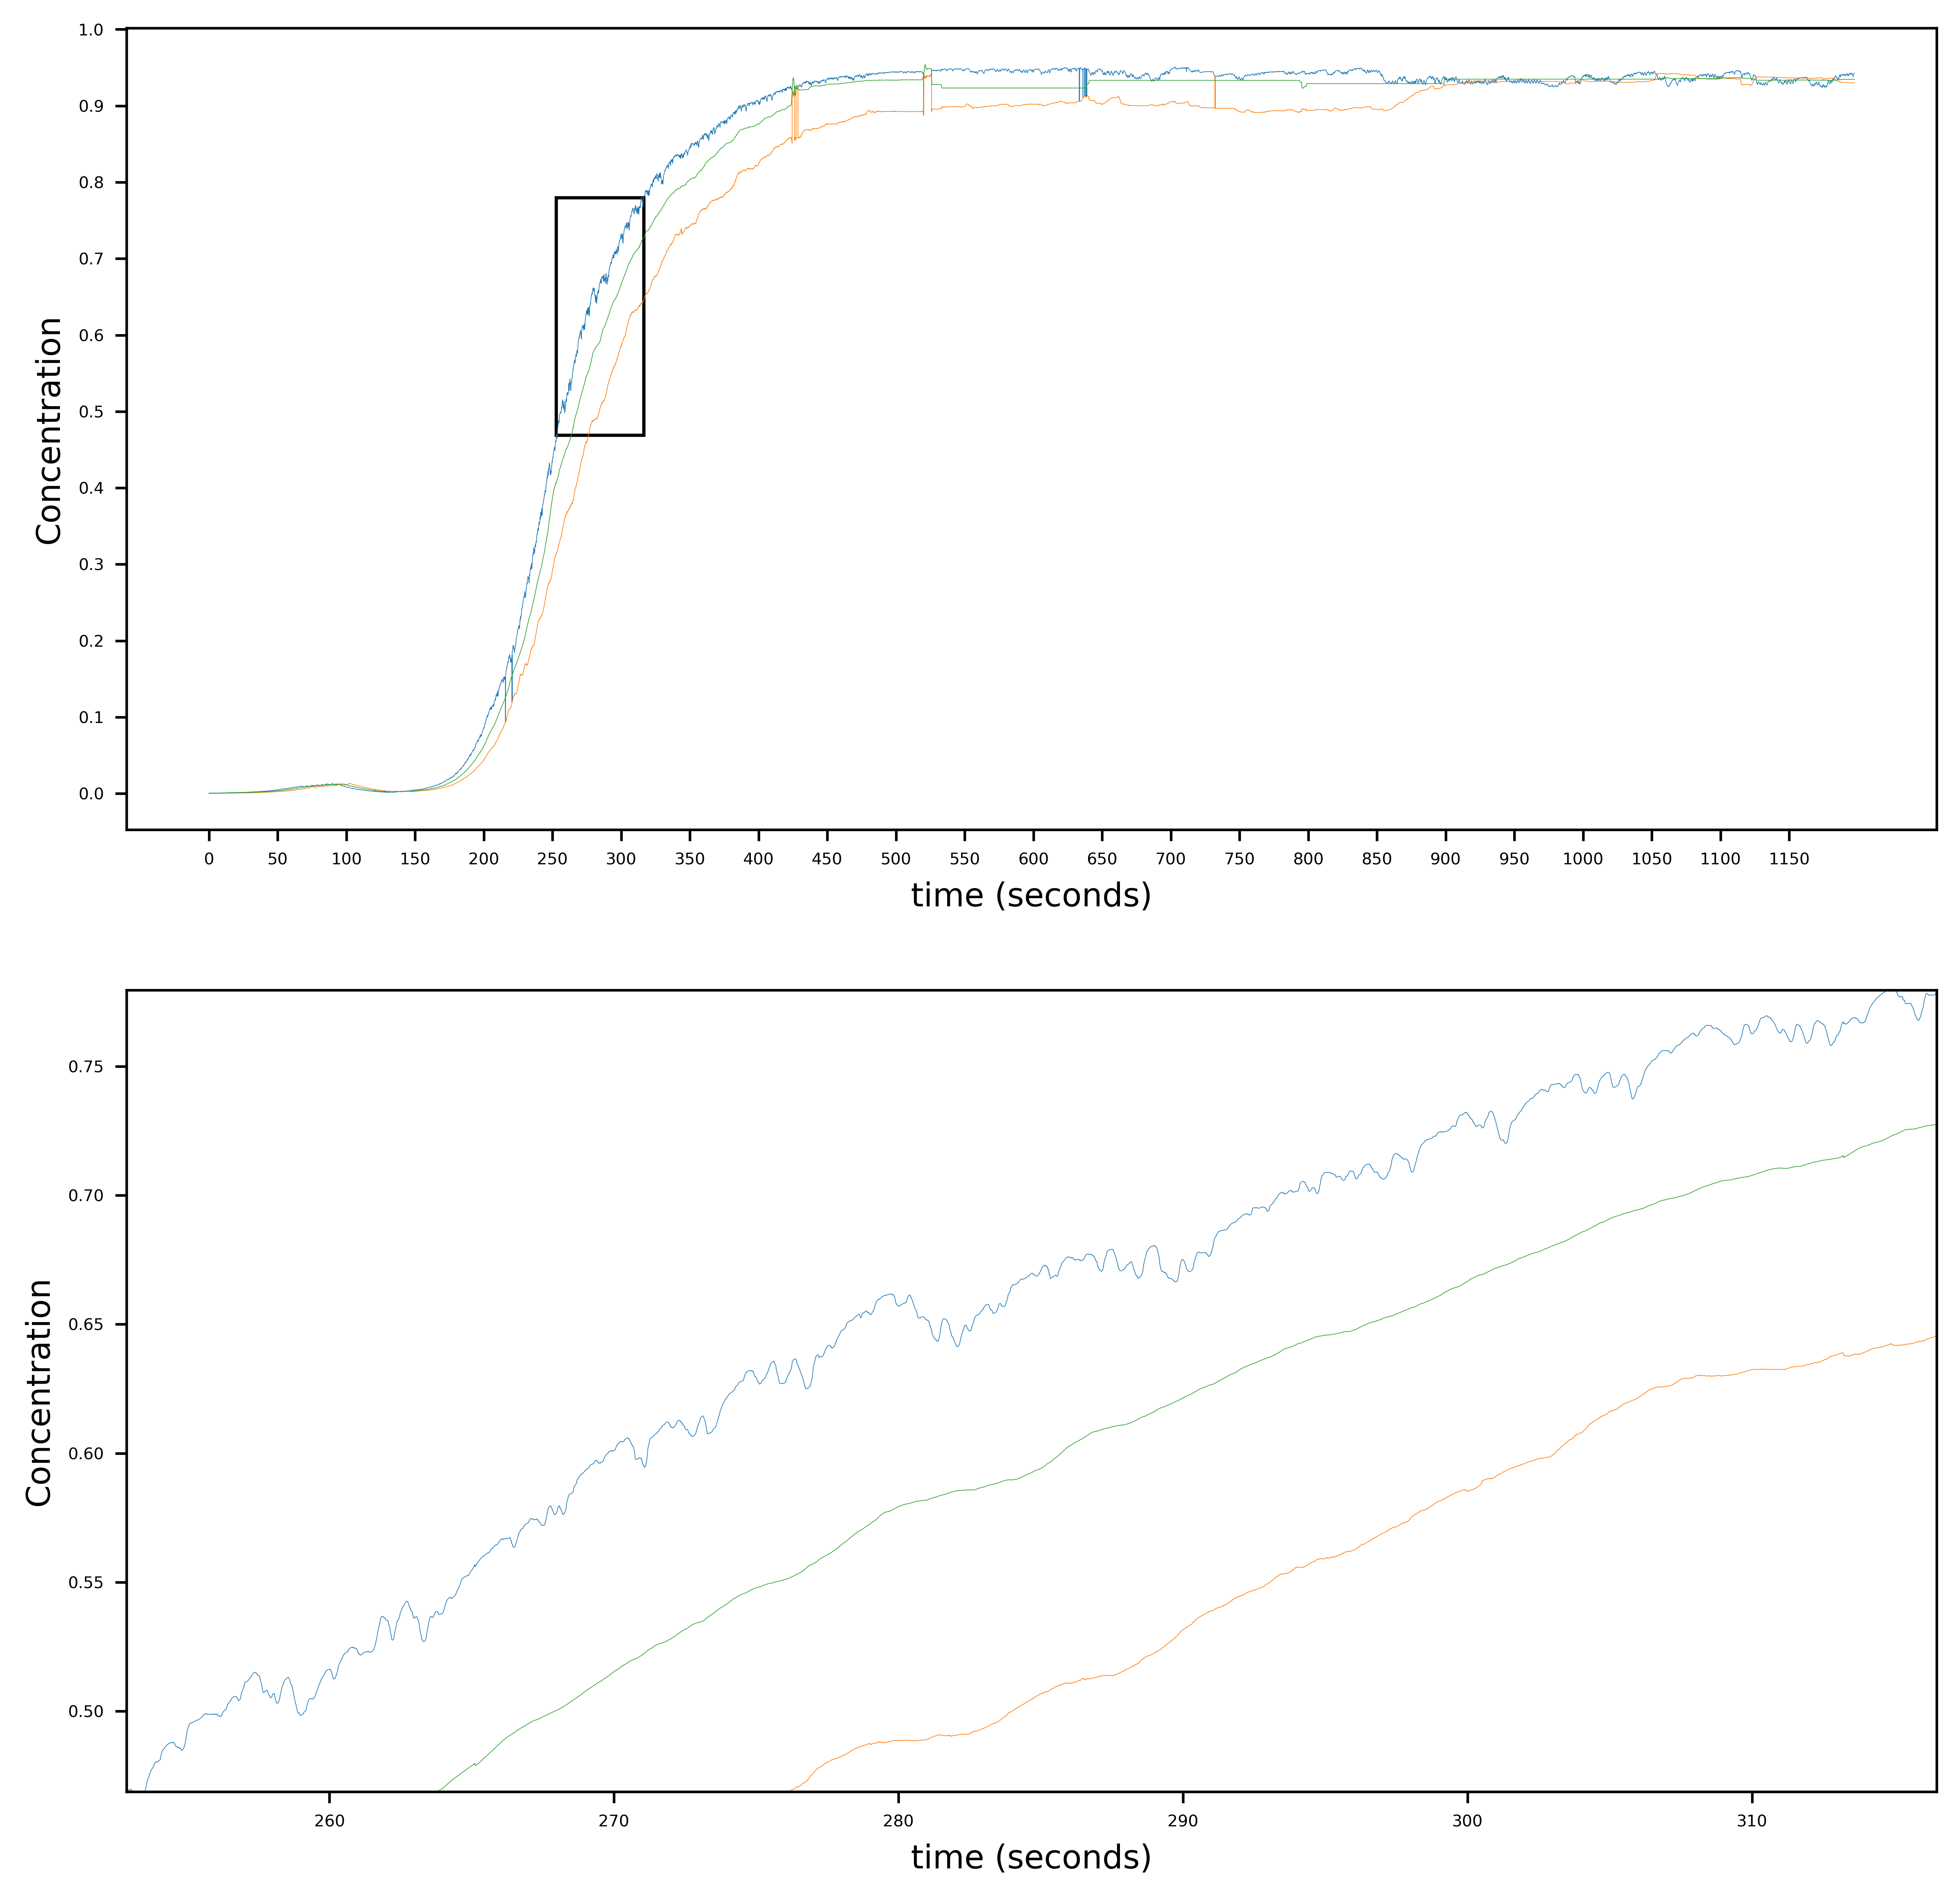

In [16]:
plot_concentration_section(concentration_change,position)

In [ ]:
#create list to plot the position of outliers in track
##head
#locates coordinates of extreme values within the df_head_tail_coords where all x and y positions are strored
extreme_values=concentration_change.loc[concentration_change['x_head_corrected'].isin(conc_extremes['x_head_corrected'].values)]
x_extreme=extreme_values['x_head_corrected'].tolist()
y_extreme=extreme_values['y_head_corrected'].tolist()

##tail
extreme_values_tail=concentration_change.loc[concentration_change['x_tail_corrected'].isin(conc_extremes_tail['x_tail_corrected'].values)]
x_extreme_tail=extreme_values_tail['x_tail_corrected'].tolist()
y_extreme_tail=extreme_values_tail['y_tail_corrected'].tolist()


In [ ]:
#show outliers in track
figsize_x=10
figsize_y=5
line_width=0.1

#plot track
head_pos_x=concentration_change['x_head_corrected']
tail_pos_x=concentration_change['x_tail_corrected']
center_pos_x=concentration_change['x_center']

head_pos_y=concentration_change['y_head_corrected']
tail_pos_y=concentration_change['y_tail_corrected']
center_pos_y=concentration_change['y_center']

fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
ax3.plot(head_pos_x,head_pos_y,linewidth=line_width,label='head')
ax3.plot(tail_pos_x,tail_pos_y,linewidth=line_width,label='tail')
ax3.plot(center_pos_x,center_pos_y,linewidth=line_width,label='center')
ax3.axvline(x=0, ymin=0, ymax=1, lw=10, alpha=.5, color='y')
plt.scatter([x_extreme], [y_extreme],s=10,facecolors='none',edgecolors='b')
plt.scatter([x_extreme_tail], [y_extreme_tail],s=10,facecolors='none',edgecolors='r')
plt.legend()
#plt.savefig('chemotaxis_worm2_conc_change_outliers.png')
plt.show()

In [ ]:
#histogram with outliers
head_conc=concentration_change['concentration_change_head']
tail_conc=concentration_change['concentration_change_tail']
center_conc=concentration_change['concentration_change_center']
head_conc=head_conc.tolist()
tail_conc=tail_conc.tolist()
center_conc=center_conc.tolist()

bins = np.linspace(-0.0015, 0.0015, 500)
plt.xticks(np.arange(-0.0015, 0.0015, step=0.00005)) 

plt.hist(head_conc, bins, alpha=0.5, label='head_conc')
plt.hist(tail_conc, bins, alpha=0.5, label='tail_conc')
plt.hist(center_conc, bins, alpha=0.5, label='center_conc')
plt.legend(loc='upper right')
plt.ylim(0, 10000)
plt.xlim(-0.00015, 0.00015)
plt.savefig('chemotaxis_worm2_concentration_change_histogram')
plt.show()

In [ ]:
#removing outliers (values bigger then 3xstd)
#for head
conc_change_head=concentration_change['concentration_change_head']

concentration_change_outliers_out_head=concentration_change[np.abs(conc_change_head-conc_change_head.mean())
                                                       <= (3*conc_change_head.std())] 
#for tail
conc_change_tail=concentration_change_outliers_out_head['concentration_change_tail']

concentration_change_outliers_out=concentration_change_outliers_out_head[np.abs(conc_change_tail-conc_change_tail.mean())
                                                       <= (3*conc_change_tail.std())]
concentration_change_outliers_out


In [ ]:
#concentraiton change plot without outliers
#concentraton_change and time
x=np.arange(199935)
head_conc=concentration_change_outliers_out['concentration_change_head']
tail_conc=concentration_change_outliers_out['concentration_change_tail']
center_conc=concentration_change_outliers_out['concentration_change_center']

head_pos_x=concentration_change_outliers_out['x_head_corrected']
tail_pos_x=concentration_change_outliers_out['x_tail_corrected']
center_pos_x=concentration_change_outliers_out['x_center']
xfig3, ax3 = plt.subplots(1,1, figsize = (10,5), dpi=600)
ax3.plot(x,head_conc,label="head")
ax3.plot(x,tail_conc,label="tail")
ax3.plot(x,center_conc,label="center")


In [ ]:
#define values for histogram without outliers
head_conc=concentration_change_outliers_out['concentration_change_head']
tail_conc=concentration_change_outliers_out['concentration_change_tail']
center_conc=concentration_change_outliers_out['concentration_change_center']
head_conc=head_conc.tolist()
tail_conc=tail_conc.tolist()
center_conc=center_conc.tolist()

In [ ]:
#conc_change histogram without outliers
bins = np.linspace(-0.0015, 0.0015, 500)
plt.xticks(np.arange(-0.0015, 0.0015, step=0.00005)) 

plt.hist(head_conc, bins, alpha=0.5, label='head_conc')
plt.hist(tail_conc, bins, alpha=0.5, label='tail_conc')
plt.hist(center_conc, bins, alpha=0.5, label='center_conc')
plt.legend(loc='upper right')
plt.ylim(0, 10000)
plt.xlim(-0.00015, 0.00015)
plt.show()


In [ ]:
os.mkdir('daniel')

In [ ]:
os.path.join(path, 'daniel')

In [ ]:
a='groups/zimmer'
b='myfolder'
c=a+b
print(c)

In [ ]:
os.path.exists(path_head_tail_all)

In [ ]:
os.getcwd()

In [ ]:
python_files=glob.glob('*.py')
print(python_files)

In [ ]:
for python_file in python_files:
    print(python_file)
    print('next')

In [ ]:
for element in [1,2,3,4,5, 8]:
    print(element)
    print(element/2)

In [ ]:
np.array([1,2,3,4,5, 8])/2

In [ ]:
for file in 1000.0:
    print(file)

# determine speed

In [ ]:
def calculate_speeds(positions_over_time):
    """
    Return a Speed dataframe from a Dataframe containing X and Y coordinates (only)
    source: https://codereview.stackexchange.com/questions/158688/calculating-speed-from-a-pandas-dataframe-with-time-x-and-y-columns
    """
    #Filter the dataframe so that it only has the input it needs
    positions_over_time=positions_over_time.filter(['X', 'Y', 'Time Elapsed'])
    time = 'Time Elapsed'

    movements_over_timesteps = (
        np.roll(positions_over_time, -1, axis=0)
        - positions_over_time)[:-1]

    speeds = np.sqrt(
        movements_over_timesteps.X ** 2 +
        movements_over_timesteps.Y ** 2
    ) / movements_over_timesteps[time]

    return pd.DataFrame({
        time: positions_over_time[time][:-1],
        'Speed': speeds,
    })

In [ ]:
#run the function
speed_df=calculate_speeds(data_df)

(0.0, 0.1)

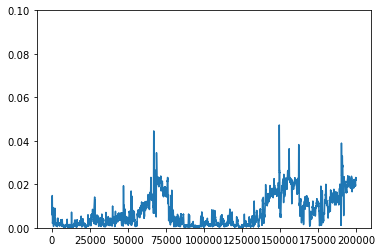

In [48]:
#plot speed
plt.plot(speed_df['Speed'].rolling(window=167,center=True).mean()*167)
plt.ylim([0, 0.1])

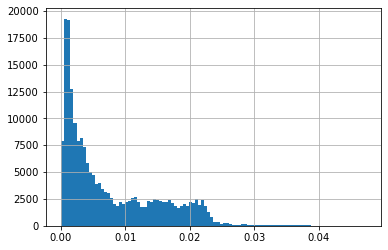

In [47]:
(speed_df['Speed'].rolling(window=167,center=True).mean()*167).hist(bins=100)